In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

print("Token loaded successfully!")

Token loaded successfully!


In [ ]:
import kagglehub

#Download latest version of Loveda dataset
path = kagglehub.dataset_download("mohammedjaveed/loveda-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.92G/8.92G [01:28<00:00, 108MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohammedjaveed/loveda-dataset/versions/1


Dataset downloaded to: /root/.cache/kagglehub/datasets/mohammedjaveed/loveda-dataset/versions/1
Found 2522 images for Train split.
Found 1669 images for Val split.
Visualizing a training batch...


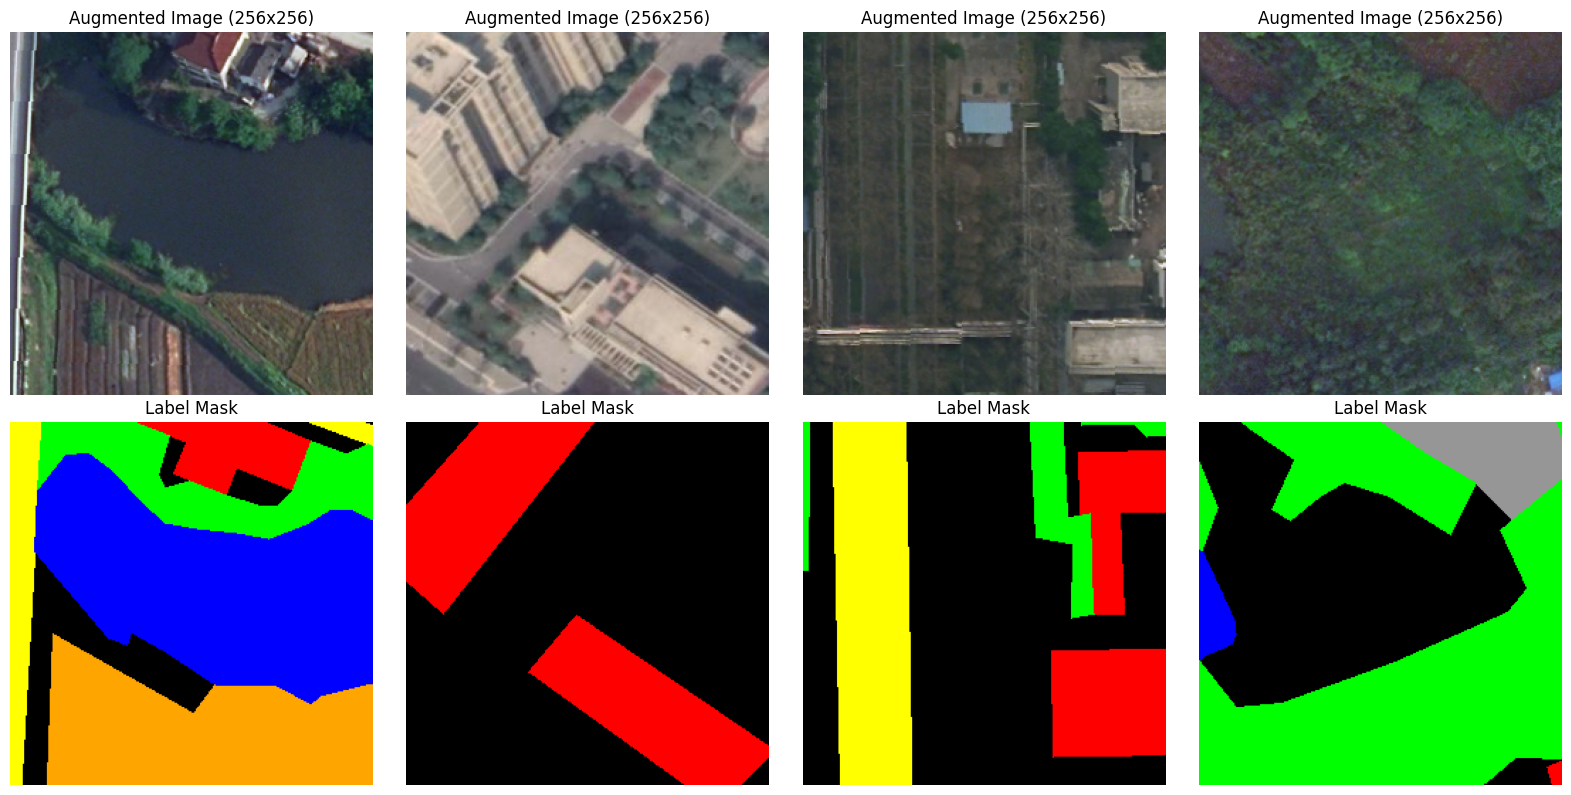

In [ ]:
#phase 1

import os
import glob
import cv2
import numpy as np
import torch
import kagglehub
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

dataset_path = path
print(f"Dataset downloaded to: {dataset_path}")


#PYTORCH DATASET CLASS
class LoveDADataset(Dataset):
    def __init__(self, root_dir, split='Train', transform=None):
        """
        Args:
            root_dir (str): Path to the extracted dataset.
            split (str): 'Train' or 'Val'.
            transform (albumentations.Compose): Data augmentation pipeline.
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        # Recursively find all images in the split directory (handles Rural/Urban subfolders)
        search_pattern = os.path.join(root_dir, split, '**', 'images_png', '*.png')
        self.image_paths = sorted(glob.glob(search_pattern, recursive=True))

        # Match mask paths based on image paths
        self.mask_paths = [p.replace('images_png', 'masks_png') for p in self.image_paths]

        print(f"Found {len(self.image_paths)} images for {self.split} split.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        #read Image and convert BGR to RGB
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask_path = self.mask_paths[idx]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = np.where(mask == 0, 255, mask - 1)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.to(torch.long)

        return image, mask

#paper specifies resizing/cutting to 256x256 and adding random flips/rotations.
train_transform = A.Compose([
    A.RandomCrop(width=256, height=256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # Standard ImageNet normalization
    ToTensorV2(),
])

val_transform = A.Compose([
    A.CenterCrop(width=256, height=256), # Fixed crop for consistent validation
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


#create Dataset instances
train_dataset = LoveDADataset(root_dir=dataset_path, split='Train', transform=train_transform)
val_dataset = LoveDADataset(root_dir=dataset_path, split='Val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)


def visualize_batch(dataloader):
    """Pulls one batch from the dataloader and plots the first 4 images/masks"""
    images, masks = next(iter(dataloader))

    # Denormalize images for viewing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    # Color map for the 7 classes (for display purposes)
    colors = [
        [0, 0, 0],       # 0: Background (Black)
        [255, 0, 0],     # 1: Building (Red)
        [255, 255, 0],   # 2: Road (Yellow)
        [0, 0, 255],     # 3: Water (Blue)
        [150, 150, 150], # 4: Barren (Gray)
        [0, 255, 0],     # 5: Forest (Green)
        [255, 165, 0]    # 6: Agriculture (Orange)
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i in range(4):
        img_np = images[i].permute(1, 2, 0).numpy()
        mask_np = masks[i].numpy()


        colored_mask = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_idx, color in enumerate(colors):
            colored_mask[mask_np == class_idx] = color

        axes[0, i].imshow(img_np)
        axes[0, i].set_title("Augmented Image (256x256)")
        axes[0, i].axis("off")

        axes[1, i].imshow(colored_mask)
        axes[1, i].set_title("Label Mask")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

print("Visualizing a training batch...")
visualize_batch(train_loader)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import numpy as np

#BASELINE ARCHITECTURE (No Custom Modules)
class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

class ASPPPooling(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        size = x.shape[-2:]
        for mod in self:
            x = mod(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class StandardASPP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.mod1 = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
        self.mod2 = ASPPConv(in_channels, out_channels, dilation=6)
        self.mod3 = ASPPConv(in_channels, out_channels, dilation=12)
        self.mod4 = ASPPConv(in_channels, out_channels, dilation=18)
        self.mod5 = ASPPPooling(in_channels, out_channels)
        self.project = nn.Sequential(nn.Conv2d(5 * out_channels, out_channels, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True), nn.Dropout(0.5))

    def forward(self, x):
        res = [self.mod1(x), self.mod2(x), self.mod3(x), self.mod4(x), self.mod5(x)]
        return self.project(torch.cat(res, dim=1))

class BaselineDeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT).features
        self.low_level_features = mobilenet[:4]
        self.high_level_features = mobilenet[4:]

        self.aspp = StandardASPP(in_channels=1280, out_channels=256)

        self.reduce_low_level = nn.Sequential(nn.Conv2d(24, 48, 1, bias=False), nn.BatchNorm2d(48), nn.ReLU(inplace=True))

        #Standard Decoder (No FPPM)
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        input_shape = x.shape[-2:]
        low_level = self.low_level_features(x)
        high_level = self.high_level_features(low_level)

        aspp_out = self.aspp(high_level)
        aspp_out = F.interpolate(aspp_out, size=low_level.shape[-2:], mode='bilinear', align_corners=False)

        low_level_reduced = self.reduce_low_level(low_level)
        decoder_in = torch.cat([low_level_reduced, aspp_out], dim=1)

        out = self.decoder(decoder_in)
        out = F.interpolate(out, size=input_shape, mode='bilinear', align_corners=False)
        return out

class MetricsHelper:
    def __init__(self, num_classes=7, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def compute_iou(self, preds, targets):
        preds = torch.argmax(preds, dim=1)
        ious = []
        for cls in range(self.num_classes):
            pred_inds = preds == cls
            target_inds = targets == cls
            intersection = (pred_inds[target_inds]).long().sum().item()
            union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection
            if union == 0:
                ious.append(float('nan'))
            else:
                ious.append(float(intersection) / float(max(union, 1)))
        return ious

    def compute_global_accuracy(self, preds, targets):
        preds = torch.argmax(preds, dim=1)
        valid_mask = targets != self.ignore_index
        correct = ((preds == targets) & valid_mask).float().sum().item()
        total = valid_mask.float().sum().item()
        return correct / max(total, 1.0)

#training
def train_baseline(model, train_loader, val_loader, num_epochs=40):
    print("--- Starting BASELINE Training (Ablation Study) ---")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on device: {device}")

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=255).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    metrics = MetricsHelper(num_classes=7, ignore_index=255)

    best_miou = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        epoch_train_loss = train_loss / len(train_loader.dataset)
        print(f"Training Loss: {epoch_train_loss:.4f}")

        model.eval()
        val_loss = 0.0
        total_iou = np.zeros(7)
        valid_classes = np.zeros(7)
        total_acc = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                batch_ious = metrics.compute_iou(outputs, masks)
                for i, iou in enumerate(batch_ious):
                    if not np.isnan(iou):
                        total_iou[i] += iou
                        valid_classes[i] += 1
                total_acc += metrics.compute_global_accuracy(outputs, masks)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        mean_ious = total_iou / np.maximum(valid_classes, 1)
        miou = np.nanmean(mean_ious)
        global_acc = total_acc / len(val_loader)

        print(f"Validation Loss: {epoch_val_loss:.4f}")
        print(f"Validation mIoU: {miou:.4f} | Global Accuracy: {global_acc:.4f}")

        if miou > best_miou:
            best_miou = miou
            #Saving weights to file
            checkpoint_path = '/content/drive/MyDrive/baseline_deeplabv3plus_model.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f"-> Baseline Model saved to {checkpoint_path} (mIoU improved to {best_miou:.4f})")

    print("\nBaseline Training Complete!")
    return model

if __name__ == "__main__":
    import os

    if not os.path.exists('/content/drive/MyDrive'):
        print("Google Drive is not mounted! Mounting it now so we can save your weights...")
        from google.colab import drive
        drive.mount('/content/drive')

    baseline_model = BaselineDeepLabV3Plus(num_classes=7)
    #Train for 40 (same as improved)
    train_baseline(baseline_model, train_loader, val_loader, num_epochs=40)



--- Starting BASELINE Training  ---
Training on device: cuda

Epoch 1/40
--------------------
Training Loss: 1.1819
Validation Loss: 1.1819
Validation mIoU: 0.2836 | Global Accuracy: 0.5734
-> Baseline Model saved to /content/drive/MyDrive/baseline_deeplabv3plus_model.pth (mIoU improved to 0.2836)

Epoch 2/40
--------------------
Training Loss: 1.1204
Validation Loss: 1.1501
Validation mIoU: 0.2918 | Global Accuracy: 0.5801

Epoch 3/40
--------------------
Training Loss: 1.0883
Validation Loss: 1.1347
Validation mIoU: 0.2975 | Global Accuracy: 0.5843
-> Baseline Model saved to /content/drive/MyDrive/baseline_deeplabv3plus_model.pth (mIoU improved to 0.2975)

Epoch 4/40
--------------------
Training Loss: 1.0501
Validation Loss: 1.1102
Validation mIoU: 0.2954 | Global Accuracy: 0.5819

Epoch 5/40
--------------------
Training Loss: 1.0214
Validation Loss: 1.0987
Validation mIoU: 0.3012 | Global Accuracy: 0.5867
-> Baseline Model saved to /content/drive/MyDrive/baseline_deeplabv3plus_mod

Loading weights from /content/drive/MyDrive/baseline_deeplabv3plus_model.pth...

Running visual inference...


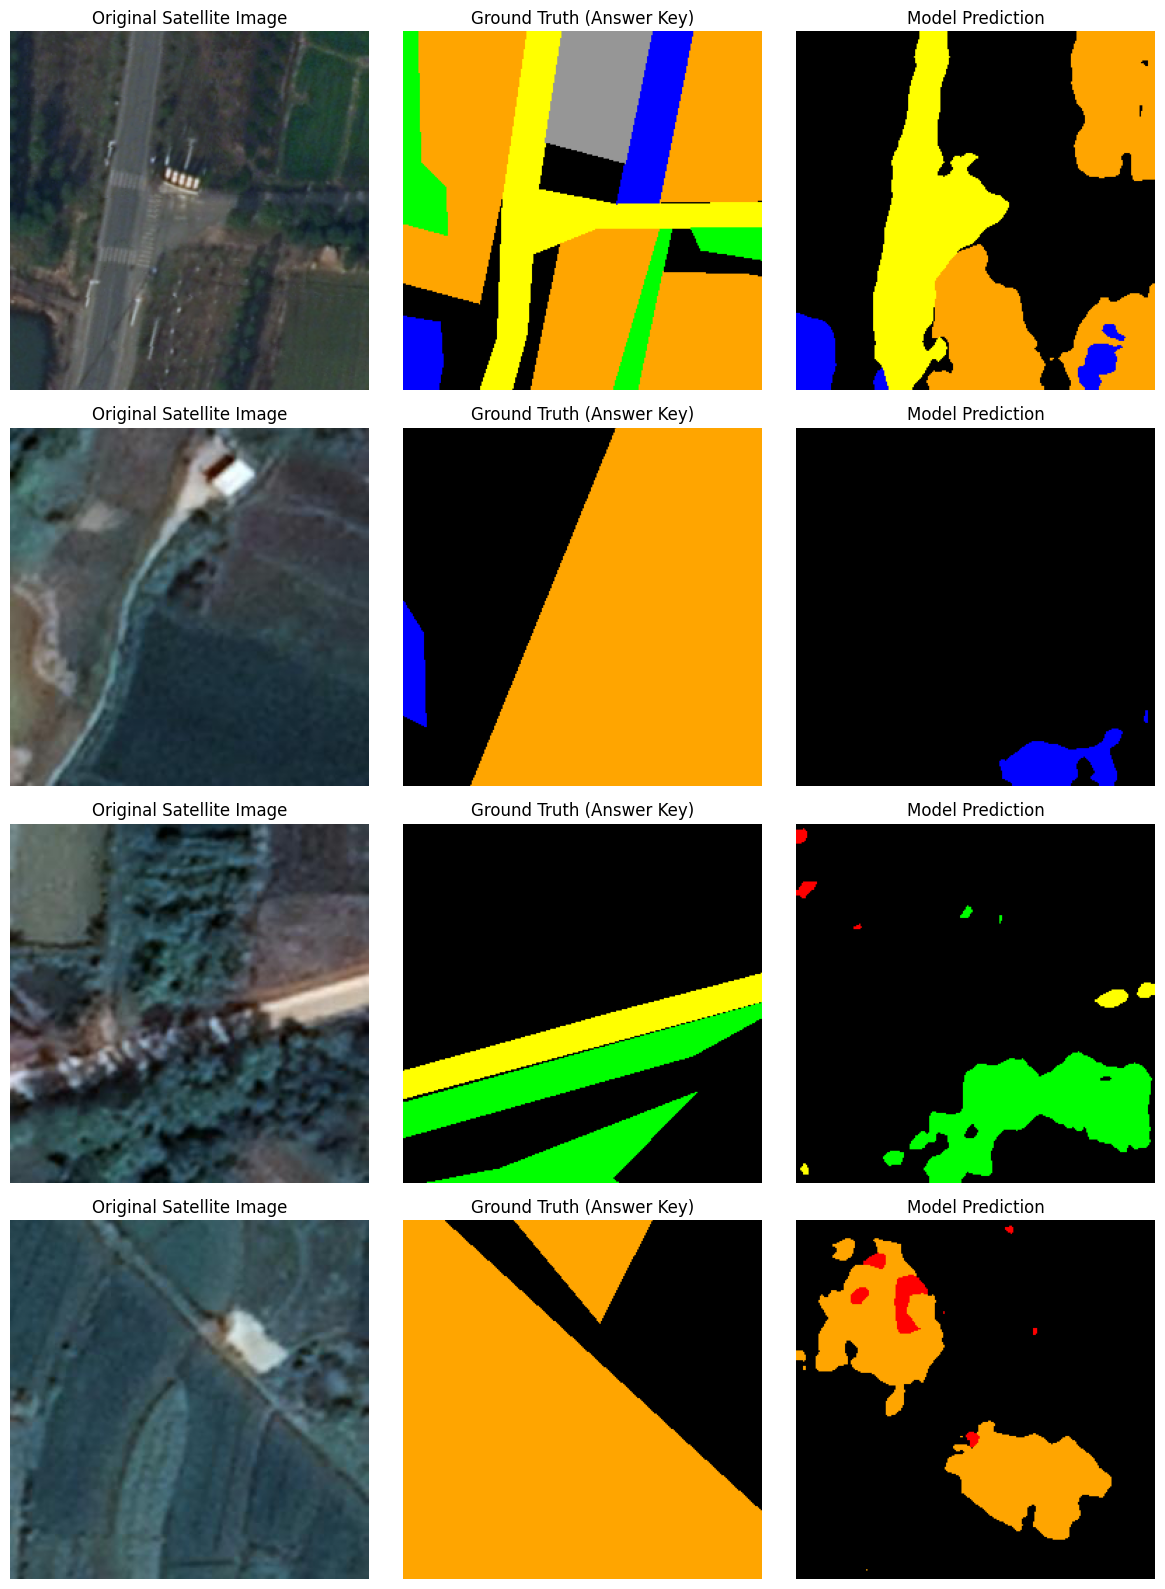


Evaluating full validation dataset...
FINAL QUANTITATIVE RESULTS
Background      IoU:  41.73%
Building        IoU:  39.18%
Road            IoU:  28.45%
Water           IoU:  47.18%
Barren          IoU:  19.95%
Forest          IoU:  26.06%
Agriculture     IoU:  42.72%
----------------------------------------
Mean IoU (mIoU)    :  35.04%
Global Accuracy    :  61.19%


In [ ]:
#testing the baseline model

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

#LOAD THE TRAINED MODEL

def load_trained_model(model_class, weights_path, device):
    """Loads the saved weights into the model architecture"""
    print(f"Loading weights from {weights_path}...")
    model = model_class(num_classes=7)

    model.load_state_dict(torch.load(weights_path, map_location=device))

    model = model.to(device)
    model.eval()
    return model


#visualisation func
def visualize_predictions(model, dataloader, device, num_images=4):
    """Runs inference on a random batch and plots Image vs Ground Truth vs Prediction"""

    #skip a random number of batches to get different images every time
    data_iter = iter(dataloader)
    skip_batches = random.randint(0, len(dataloader) - 1)
    for _ in range(skip_batches):
        next(data_iter)

    images, masks = next(data_iter)

    images_gpu = images.to(device)

    print("\nRunning visual inference...")
    with torch.no_grad():
        outputs = model(images_gpu)
        #Convert logits to final class predictions (argmax across channel dimension)
        predictions = torch.argmax(outputs, dim=1).cpu()

    #Move images and masks back to CPU for matplotlib(was using gpu bfore)
    images = images.cpu()
    masks = masks.cpu()

    colors = [
        [0, 0, 0],       # 0: Background (Black)
        [255, 0, 0],     # 1: Building (Red)
        [255, 255, 0],   # 2: Road (Yellow)
        [0, 0, 255],     # 3: Water (Blue)
        [150, 150, 150], # 4: Barren (Gray)
        [0, 255, 0],     # 5: Forest (Green)
        [255, 165, 0]    # 6: Agriculture (Orange)
    ]

    def map_to_color(tensor_mask):
        """Converts a 2D class index tensor into a 3D RGB image"""
        mask_np = tensor_mask.numpy()
        colored_mask = np.zeros((256, 256, 3), dtype=np.uint8)

        for class_idx, color in enumerate(colors):
            colored_mask[mask_np == class_idx] = color

        colored_mask[mask_np == 255] = [255, 255, 255] #Make unknown pixels white

        return colored_mask

    # Denormalize images for viewing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # PLOTTING
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

    for i in range(num_images):
        #Original Image
        img_denorm = images[i] * std + mean
        img_denorm = torch.clamp(img_denorm, 0, 1)
        axes[i, 0].imshow(img_denorm.permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Original Satellite Image")
        axes[i, 0].axis("off")

        #Ground Truth Mask
        gt_colored = map_to_color(masks[i])
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title("Ground Truth (Answer Key)")
        axes[i, 1].axis("off")

        #Model Prediction
        pred_colored = map_to_color(predictions[i])
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title(f"Model Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

#FULL DATASET QUANTITATIVE EVALUATION
def evaluate_full_dataset(model, dataloader, device, num_classes=7, ignore_index=255):
    """Calculates final paper metrics across the entire validation dataset"""
    print("\nEvaluating full validation dataset...")

    total_iou = np.zeros(num_classes)
    valid_classes = np.zeros(num_classes)
    total_correct = 0
    total_pixels = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Per-class IoU Calculation
            for cls in range(num_classes):
                pred_inds = preds == cls
                target_inds = masks == cls

                intersection = (pred_inds[target_inds]).long().sum().item()
                union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection

                if union > 0:
                    total_iou[cls] += float(intersection) / float(max(union, 1))
                    valid_classes[cls] += 1

            # Global Accuracy Calculation
            valid_mask = masks != ignore_index
            total_correct += ((preds == masks) & valid_mask).float().sum().item()
            total_pixels += valid_mask.float().sum().item()

    # Averages
    mean_ious = total_iou / np.maximum(valid_classes, 1)
    miou = np.nanmean(mean_ious)
    global_acc = total_correct / max(total_pixels, 1.0)

    class_names = ["Background", "Building", "Road", "Water", "Barren", "Forest", "Agriculture"]

    print("FINAL QUANTITATIVE RESULTS")
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<15} IoU: {mean_ious[i]*100:>6.2f}%")
    print("-" * 40)
    print(f"{'Mean IoU (mIoU)':<15}    : {miou*100:>6.2f}%")
    print(f"{'Global Accuracy':<15}    : {global_acc*100:>6.2f}%")


if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    weights_path = '/content/drive/MyDrive/baseline_deeplabv3plus_model.pth'
    try:
        #load the model
        trained_model = load_trained_model(BaselineDeepLabV3Plus, weights_path, device)

        #Run the visualizer (randomly selects new images)
        visualize_predictions(trained_model, val_loader, device, num_images=4)

        #eval
        evaluate_full_dataset(trained_model, val_loader, device)

    except FileNotFoundError:
        print(f"Error: Could not find the weights file at {weights_path}.")
        print("Ensure your Google Drive is mounted and the path is correct.")